# Graph 5 - Exercise

Make the graph on the right! You need to implement an Automatic Higher or Lower Game.

Set the bounds to between 1 to 20. The Graph has to keep guessing (max number of guesses is 7) where if the guess is correct, then it stops, but if not we keep looping until we hit the max limit of 7.

Each time a number is guessed, the hint node should say higher or lower and the graph should account for this information and guess the next guess accordingly.

Input: {"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20}

Hint: It will need to adjust its bounds after every guess based on the hint provided by the hint node.

In [39]:
from typing import Dict, List, TypedDict
import random
from langgraph.graph import StateGraph, END

In [40]:
class AgentState(TypedDict):
    player_name: str
    target_number: int
    guesses: List[int]
    lower_bound: int
    upper_bound: int
    result: str

In [51]:
def setup_node(state: AgentState) -> AgentState:
    """Setup Node to config the game"""
    state["player_name"] = state["player_name"]
    state["target_number"] = random.randint(1, 20)
    state["guesses"] = [int]
    state["lower_bound"] = 1
    state["upper_bound"] = 20
    result = "Let's start the game!"

    return state

def guess_node(state: AgentState) -> AgentState:
    """Verify if the user correctly guessed the value"""
    value = int(input("Type a value between 0 and 20"))
    state["guesses"].append(value)

    return state

def verify_response(state: AgentState) -> AgentState:

    if len(state["guesses"]) >= 7:
        state["result"] = f"Game over! You didn't guess the number. The number was {state['target_number']}."
        return "finish_game"

    if state["guesses"][-1] == state["target_number"]:
        state["result"] = f"Correct! {state['player_name']} guessed the number {state['target_number']} in {len(state['guesses'])} attempts."
        return "right"

    return "wrong"

def hint_node(state: AgentState) -> AgentState:
    """Give a hint to the user"""

    if state["guesses"][-1] < state["target_number"]:
        state["result"] = "Higher!"
        state["lower_bound"] = state["guesses"][-1] + 1
    elif state["guesses"][-1] > state["target_number"]:
        state["result"] = "Lower!"
        state["upper_bound"] = state["guesses"][-1] - 1
    else:
        state["result"] = f"Correct! The targer number was {state["target_number"]}"
        return state

    print(state["result"])

    return state

In [52]:
graph = StateGraph(AgentState)

graph.add_node("setup", setup_node)
graph.add_node("guess", guess_node)
graph.add_node("hint", hint_node)
graph.add_edge("setup", "guess")
graph.add_edge("guess", "hint")

graph.add_conditional_edges(
    "hint", #source node
    verify_response, # action
    {
        "finish_game": END, # destination nodes (edge:node)
        "right": END, # destination nodes (edge:node)
        "wrong": "guess" # destination nodes (edge:node)
    } # mapping
)

graph.set_entry_point("setup")

app = graph.compile()

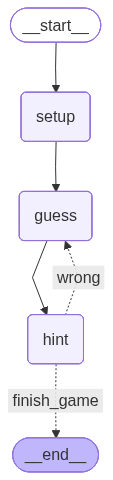

In [53]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [54]:
result = app.invoke({"player_name": "Student", "guesses": [], "attempts": 0, "lower_bound": 1, "upper_bound": 20})
print(result["result"])

Higher!
Higher!
Higher!
Lower!
Lower!
Correct! The targer number was 16
